In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [3]:
from Compression.Benchmarks.MOPED import moped
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow
from Compression.ib import IB, Bounds
from Compression.mine import Mine
from Compression.tuba import TUBA, DV_with_Jensen

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance

from SupernovaDataset.config import DATAPOINT_SIZE, DATA_VARIANCE_SCALE, LOAD_DATASET
from SupernovaDataset.config import NUM_TRAIN, NUM_TEST, LATENT_SIZE
from SupernovaDataset.dataset_creation import create_torch_supernovae_dataset, create_synthetic_supernovae_dataset


In [4]:
bounds = [
    Bounds(name="BA_KDE", cond_prob_model_class=ConditionalKDE, **{"init_std": 1, "num_kde_points": 10}),
    Bounds(name="BA_NF", cond_prob_model_class=ConditionalNormalizingFlow, **{"num_flows": 8}),
    Bounds(name="DV", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 0e0}),
    # Bounds(name="DV_with_Jensen", cond_prob_model_class=DV_with_Jensen, **{"y_dim": 1, "z_dim": LATENT_SIZE}),
    Bounds(name="MINE", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 1e-2}),
    Bounds(name="TUBA", cond_prob_model_class=TUBA, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 400}),
    Bounds(name="NWJ", cond_prob_model_class=TUBA, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 400, "a": lambda z: torch.tensor(np.exp(1.0), device=device)})
]

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)

Running on device: cuda


## Train MOPED

In [6]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]
moped_fid_val = np.array([70.0**2])

b, F, d = moped(moped_fid_val, cov, estimator_given_theta)
def moped_model(data):
    if (type(data) != np.ndarray):
        data = data# .detach().cpu().numpy()
    return data[:, :DATAPOINT_SIZE] @ b.T

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)


## Train IBs

### Training data

In [7]:
train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST, epsilon=0.1)

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

Creating sample: 10000 of 10000
Creating sample: 50000 of 50000


In [8]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [9]:
compressors = [Compressor() for _ in bounds]
ib_models = [
    IB(
        encoder=IBCompressor(encoder=compressor, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        cond_prob_model=bound.cond_prob_model(**bound.cond_prob_model_kwargs),
        beta=0e-1,
        reg_weight=4e-2,
        reg_type=0,
        optim_func=torch.optim.Adam,
        lr=1e-4
        ).to(device)
    for compressor, bound in zip(compressors, bounds)
]

h02s = train_sims_data[:, -1:]
h02_norm = (h02s - h02s.mean()) / h02s.std()

Training with bound: BA_KDE
Epoch 1: Loss=3.1206, log_q=-3.0908,, reg. loss=0.0298, beta * KL=0.5287
Epoch 10: Loss=3.0165, log_q=-3.0164,, reg. loss=0.0001, beta * KL=44.7605


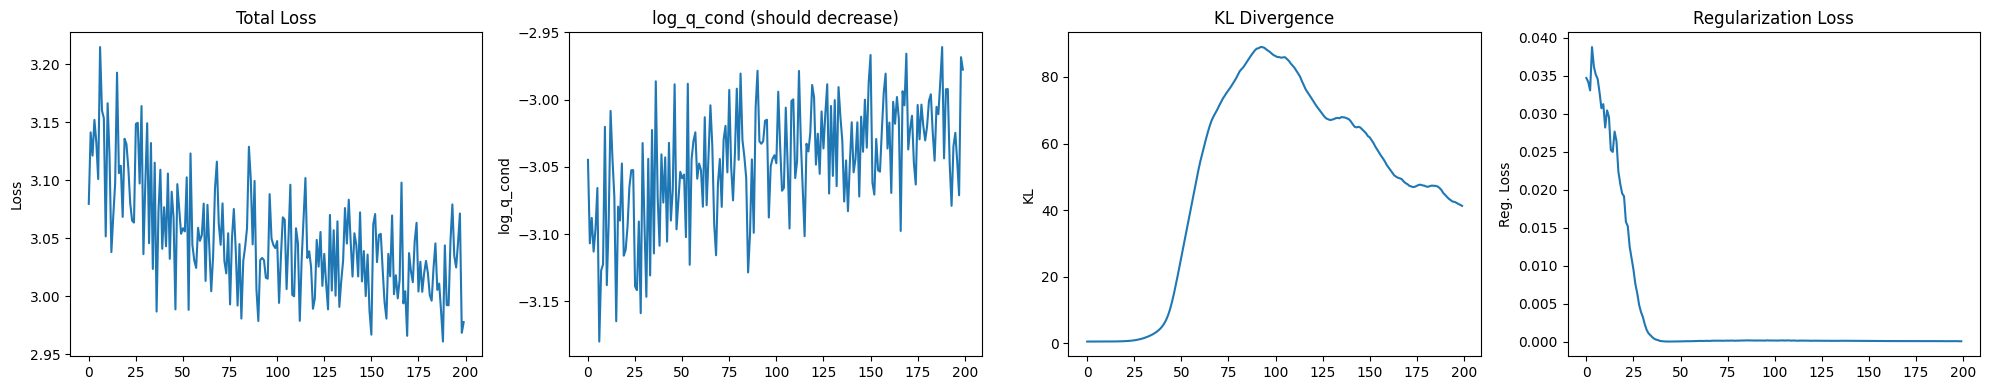

Training with bound: BA_NF
Epoch 1: Loss=4.2878, log_q=-4.2517,, reg. loss=0.0361, beta * KL=0.5106
Epoch 10: Loss=-0.3699, log_q=0.3700,, reg. loss=0.0000, beta * KL=34.8159


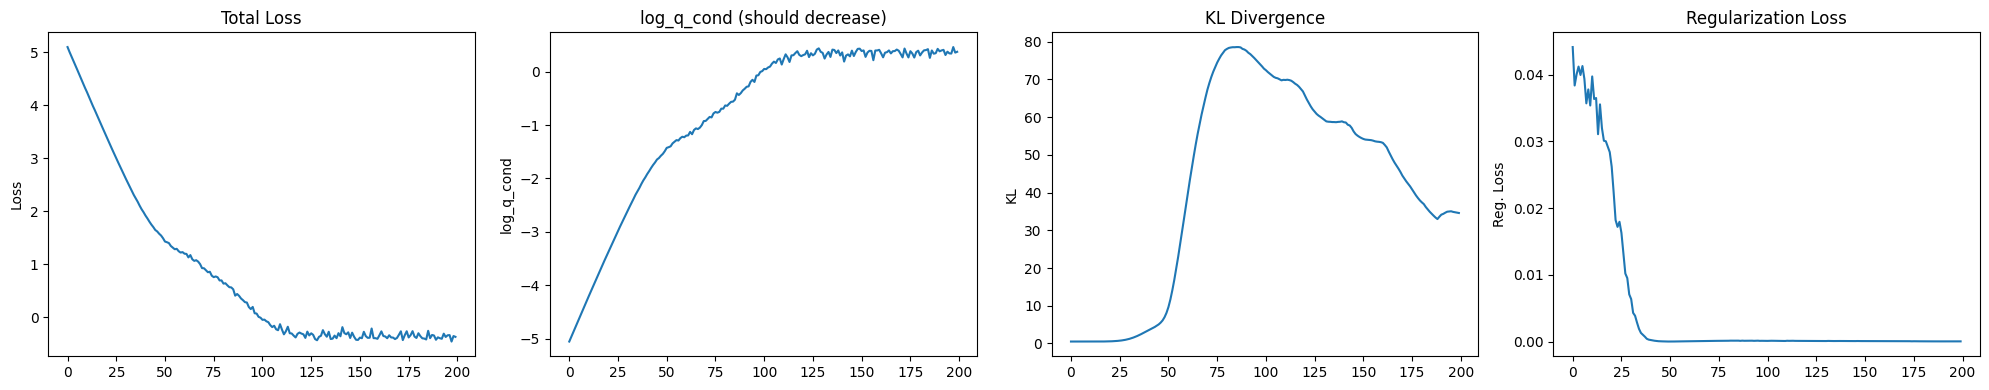

Training with bound: DV
Epoch 1: Loss=0.4277, log_q=-0.3965,, reg. loss=0.0312, beta * KL=0.5418
Epoch 10: Loss=-0.2591, log_q=0.2591,, reg. loss=0.0000, beta * KL=21.2727


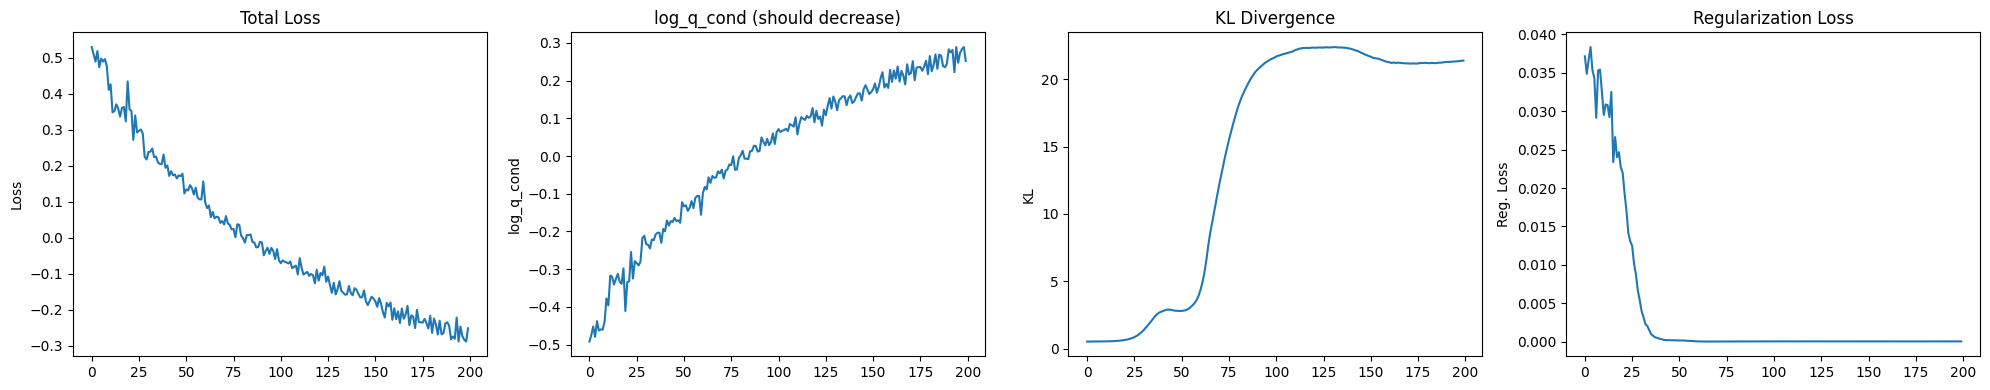

Training with bound: MINE
Epoch 1: Loss=2.1962, log_q=-2.1614,, reg. loss=0.0348, beta * KL=0.5101
Epoch 10: Loss=0.0589, log_q=-0.0587,, reg. loss=0.0002, beta * KL=83.7851


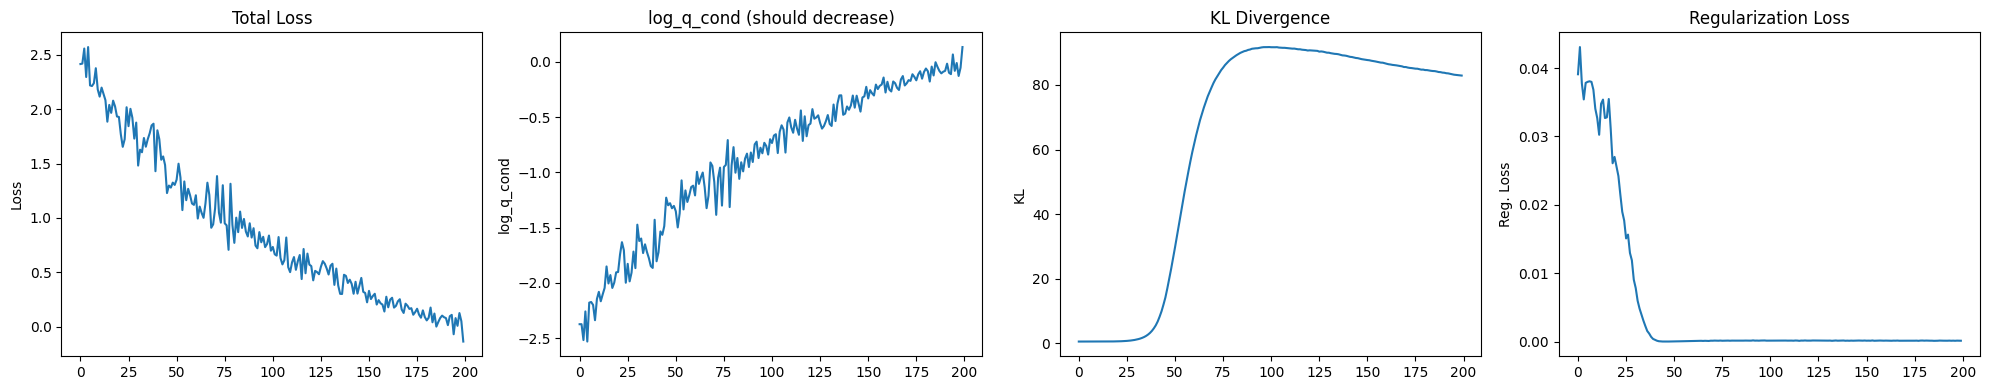

Training with bound: TUBA
Epoch 1: Loss=0.0513, log_q=-0.0192,, reg. loss=0.0321, beta * KL=0.5330
Epoch 10: Loss=-1.4157, log_q=1.4158,, reg. loss=0.0001, beta * KL=62.9281


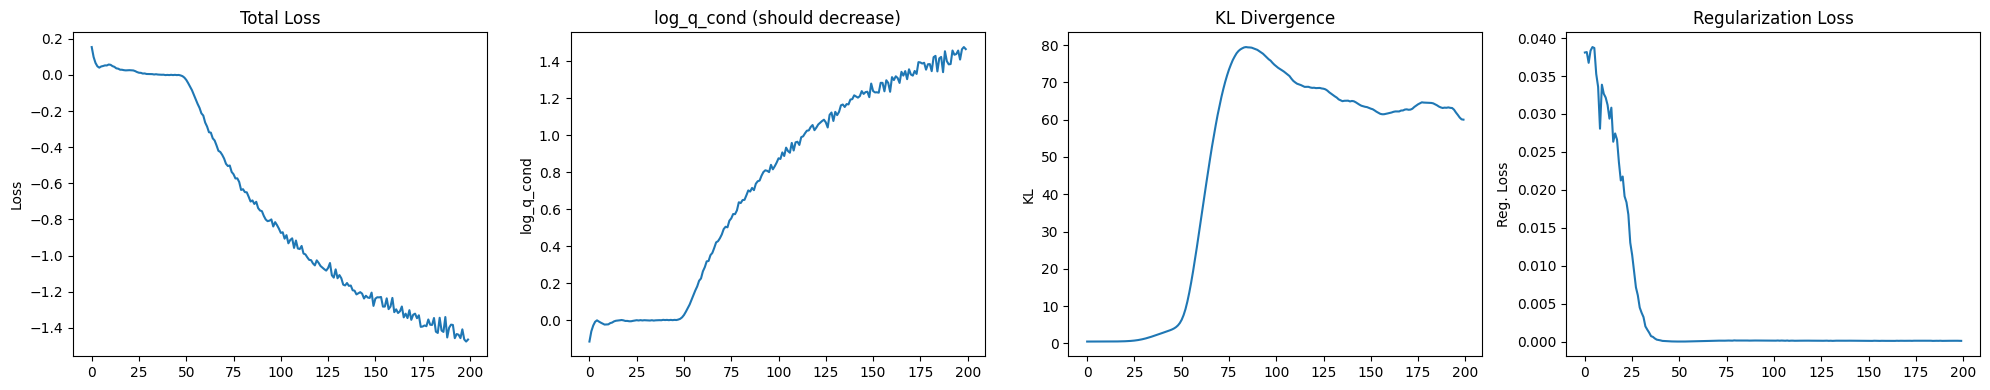

Training with bound: NWJ
Epoch 1: Loss=0.1809, log_q=-0.1452,, reg. loss=0.0357, beta * KL=0.5174
Epoch 10: Loss=-1.3619, log_q=1.3621,, reg. loss=0.0001, beta * KL=72.9069


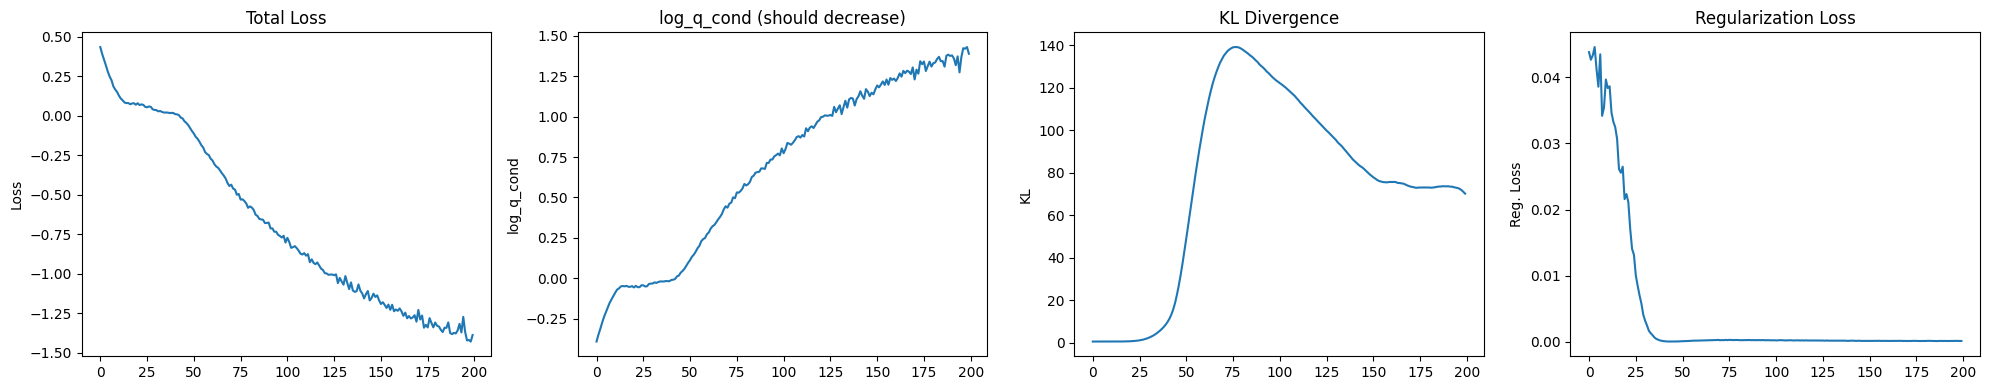

In [10]:
for i, bound in enumerate(bounds):
    print(f"Training with bound: {bound.name}")
    ib_model = ib_models[i]
    ib_model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=h02_norm,
        nepochs=10,
        batch_size=512,
        print_losses=True
    )
    assert not np.isnan(ib_model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

## Sweeping over epsilons

In [11]:
epsilons = np.linspace(0.0, 3e-1, 7)

In [12]:
moped_scores = []
moped_score_errors = []
mi_bound_scores = [[] for _ in bounds]
mi_bound_score_errors = [[] for _ in bounds]
for eps in epsilons:
    # Generate dataset with current epsilon
    test_sims_data, _, _ = create_torch_supernovae_dataset(NUM_TRAIN*20, 1, epsilon=eps, print_status=False)
    # Evaluate MOPED compression/reconstruction score


    moped_sigma, _, _, moped_std_error = evaluate_posterior_covariance(
        moped_model,
        test_sims_data[:, :DATAPOINT_SIZE],
        test_sims_data[:, -1:],
        plot_results=False,
        print_results=False
    )

    moped_sigma += 1e-6  # Avoid division by zero

    moped_scores.append(1.0 / (moped_sigma**2))
    moped_score_errors.append(2.0 * moped_std_error.mean() / (moped_sigma ** 3))

    for i, bound in enumerate(bounds):
        ib_model = ib_models[i]
        # Evaluate Neural MI Bound compression score
        mi_bound_sigma, _, _, mi_bound_std_error = evaluate_posterior_covariance(
            ib_model,
            test_sims_data[:, :DATAPOINT_SIZE].to(device),
            test_sims_data[:, -1:].to(device),
            plot_results=False,
            print_results=False
        )
        mi_bound_scores[i].append(1.0 / (mi_bound_sigma**2))
        mi_bound_score_errors[i].append(2.0 * mi_bound_std_error.mean() / (mi_bound_sigma ** 3))
        print(f"Epsilon {eps:<10.3f} Evaluated: {bound.name}: score={mi_bound_scores[i][-1]:.3f}+/-{mi_bound_score_errors[i][-1]:.3f}")

    print(f"Epsilon {eps:<10.3f}: MOPED score = {moped_scores[-1]:.3f}+/-{moped_score_errors[-1]:.3f}")

C:\Users\srish\AppData\Local\Temp\ipykernel_29912\3665724087.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return data[:, :DATAPOINT_SIZE] @ b.T


Epsilon 0.000      Evaluated: BA_KDE: score=0.057+/-0.011
Epsilon 0.000      Evaluated: BA_NF: score=0.063+/-0.006
Epsilon 0.000      Evaluated: DV: score=0.049+/-0.010
Epsilon 0.000      Evaluated: MINE: score=0.050+/-0.004
Epsilon 0.000      Evaluated: TUBA: score=0.063+/-0.005
Epsilon 0.000      Evaluated: NWJ: score=0.062+/-0.005
Epsilon 0.000     : MOPED score = 0.063+/-0.013
Epsilon 0.050      Evaluated: BA_KDE: score=0.059+/-0.009
Epsilon 0.050      Evaluated: BA_NF: score=0.067+/-0.007
Epsilon 0.050      Evaluated: DV: score=0.051+/-0.006
Epsilon 0.050      Evaluated: MINE: score=0.054+/-0.008
Epsilon 0.050      Evaluated: TUBA: score=0.067+/-0.008
Epsilon 0.050      Evaluated: NWJ: score=0.066+/-0.007
Epsilon 0.050     : MOPED score = 0.067+/-0.007
Epsilon 0.100      Evaluated: BA_KDE: score=0.062+/-0.006
Epsilon 0.100      Evaluated: BA_NF: score=0.068+/-0.016
Epsilon 0.100      Evaluated: DV: score=0.052+/-0.004
Epsilon 0.100      Evaluated: MINE: score=0.055+/-0.007
Epsilon

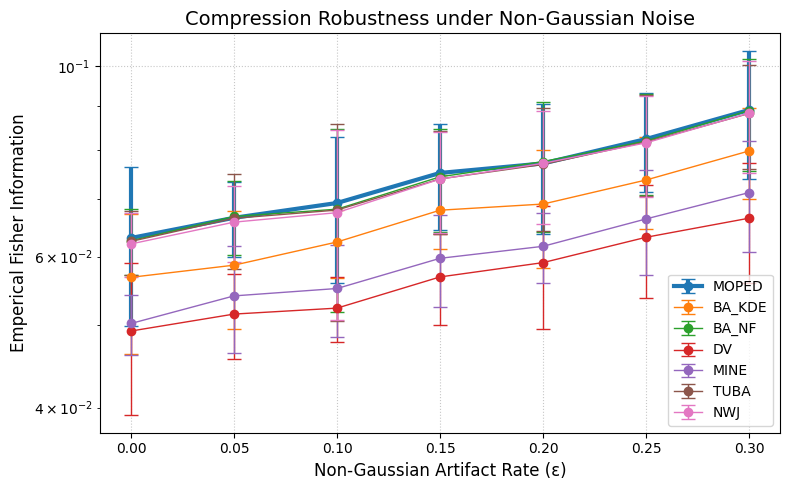

In [13]:
plt.figure(figsize=(8, 5))

# Use fmt='-o' to draw a solid line (-) with circle markers (o)
# Matplotlib will automatically use the same color for the line, marker, and error bars
plt.errorbar(
    epsilons, 
    moped_scores, 
    yerr=moped_score_errors, 
    fmt='-o', 
    capsize=5, 
    label="MOPED", 
    linewidth=3
)

for i, bound in enumerate(bounds):
    plt.errorbar(
        epsilons, 
        mi_bound_scores[i], 
        yerr=mi_bound_score_errors[i], 
        fmt='-o', 
        capsize=5, 
        label=f"{bound.name}",
        linewidth=1
    )
    # if i == 1:
    #     break

# Updated the labels to match the metrics we discussed!
plt.xlabel("Non-Gaussian Artifact Rate (\u03B5)", fontsize=12)
plt.ylabel("Emperical Fisher Information", fontsize=12)

plt.yscale('log')

plt.title("Compression Robustness under Non-Gaussian Noise", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

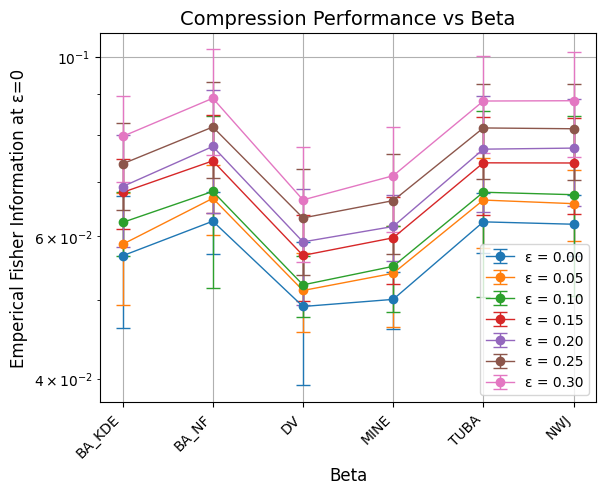

: 

In [ ]:
FI_at_eps = [[mi_bound_scores[i][j] for i in range(len(bounds))] for j in range(len(epsilons))]
FI_at_eps_errors = [[mi_bound_score_errors[i][j] for i in range(len(bounds))] for j in range(len(epsilons))]
for j in range(len(epsilons)):
    plt.errorbar(
            [bound.name for bound in bounds],
            FI_at_eps[j], 
            yerr=FI_at_eps_errors[j],
            fmt='-o', 
            capsize=5,
            label=f"\u03B5 = {epsilons[j]:.2f}",
            linewidth=1
        )
    # if j == 3:
    #     break
plt.yscale('log')
# plt.ylim([0, 3e-2])
plt.xticks([bound.name for bound in bounds], rotation=45, ha='right', fontsize=10)

plt.xlabel("Beta", fontsize=12)
plt.ylabel("Emperical Fisher Information at \u03B5=0", fontsize=12)
plt.title("Compression Performance vs Beta", fontsize=14)
plt.legend()
plt.grid()
plt.show()